# Q-Learning Walkthrough

A short notebook that trains the `QLearningAgent` for a few episodes and shows the training curves and Q-policy heatmap.
Edit the `episodes` variable below to run longer experiments.

In [5]:
import sys
from pathlib import Path

# Add project root to path so imports work
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from envs import MazeEnv
from agents import QLearningAgent
from training import Trainer, get_q_learning_config

# Create environment and agent
env = MazeEnv(difficulty="easy")
agent = QLearningAgent(env=env, **get_q_learning_config())
trainer = Trainer(env=env, agent=agent)

episodes = 100 # change to a larger number to train longer

In [6]:
# Run training (short)
logger = trainer.train(n_episodes=episodes, verbose=True, verbose_interval=max(1, episodes//5))
print('Training finished. Episodes logged:', len(logger.rewards))

Episode    20/100 | Reward:  -24.68 | Success Rate: 15.0% | Steps:   84
Episode    40/100 | Reward:  -18.38 | Success Rate: 30.0% | Steps:   79
Episode    60/100 | Reward:  -14.70 | Success Rate: 35.0% | Steps:   77
Episode    80/100 | Reward:    0.75 | Success Rate: 100.0% | Steps:   28
Episode   100/100 | Reward:    1.53 | Success Rate: 95.0% | Steps:   46
Training finished. Episodes logged: 100


(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Q-Learning Policy Heatmap'}>)

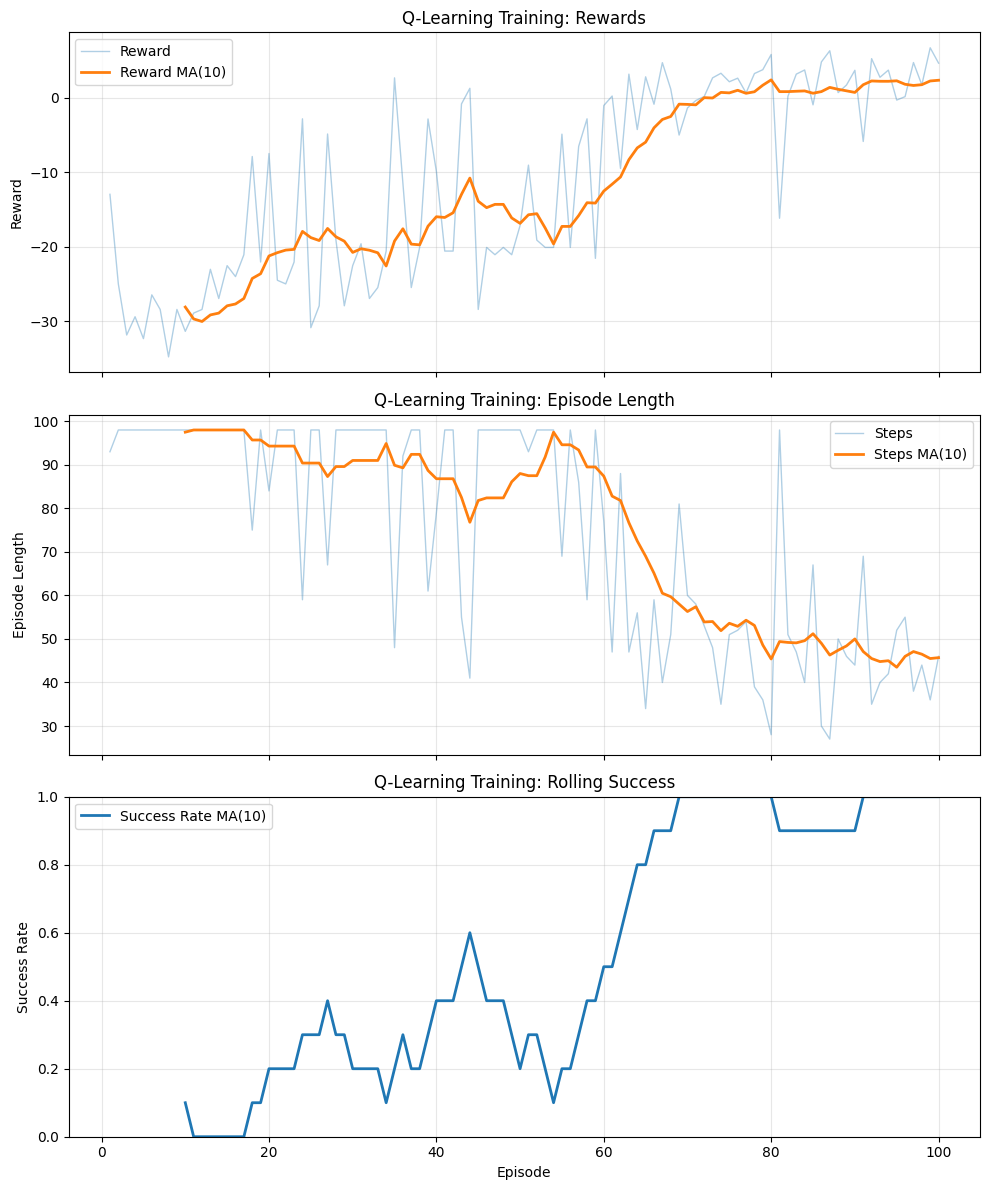

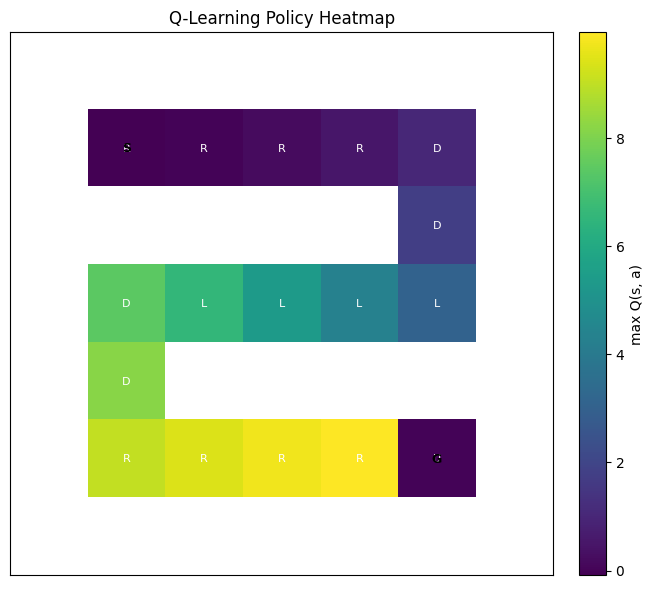

In [7]:
# Plot training curves and policy heatmap
trainer.plot_training(moving_average_window=10)
trainer.plot_q_policy_heatmap()

You can export results programmatically using the `trainer.logger.export_csv()` method and the trainer's plotting helpers.